In [4]:
import numpy as np
from scipy.integrate import quad

alpha = 1 / 137
m_e = 9.10938356e-31
c = 299792458
eV = 1.602176634e-19


Z = 2
a0 = 1.0

norm_1s = 2 * Z**1.5
norm_3p = (4 / (81 * np.sqrt(6))) * Z**1.5

def R_10(r):
    return norm_1s * np.exp(-Z * r)

def R_31(r):
    x = Z * r
    return norm_3p * x * (6 - x) * np.exp(-x / 3)

def inner_integral(r1):
    integrand = lambda r2: (r2**3) * R_10(r2) * R_31(r2)
    return quad(integrand, 0, r1, limit=100)[0]

def K_integral():
    integrand = lambda r1: R_10(r1) * R_31(r1) * inner_integral(r1)
    return (2 / 3) * quad(integrand, 0, np.inf, limit=100)[0]

K_val = K_integral()

Delta_E_J = 2 * K_val * 0.5 * alpha**2 * m_e * c**2
Delta_E_eV = Delta_E_J / eV

print(f"K (in 1/a0): {K_val:.6f}")
print(f"singlet/triplet splitting $\Delta_E$: {Delta_E_eV:.3f} eV")


K (in 1/a0): 0.009064
singlet/triplet splitting $\Delta_E$: 0.247 eV


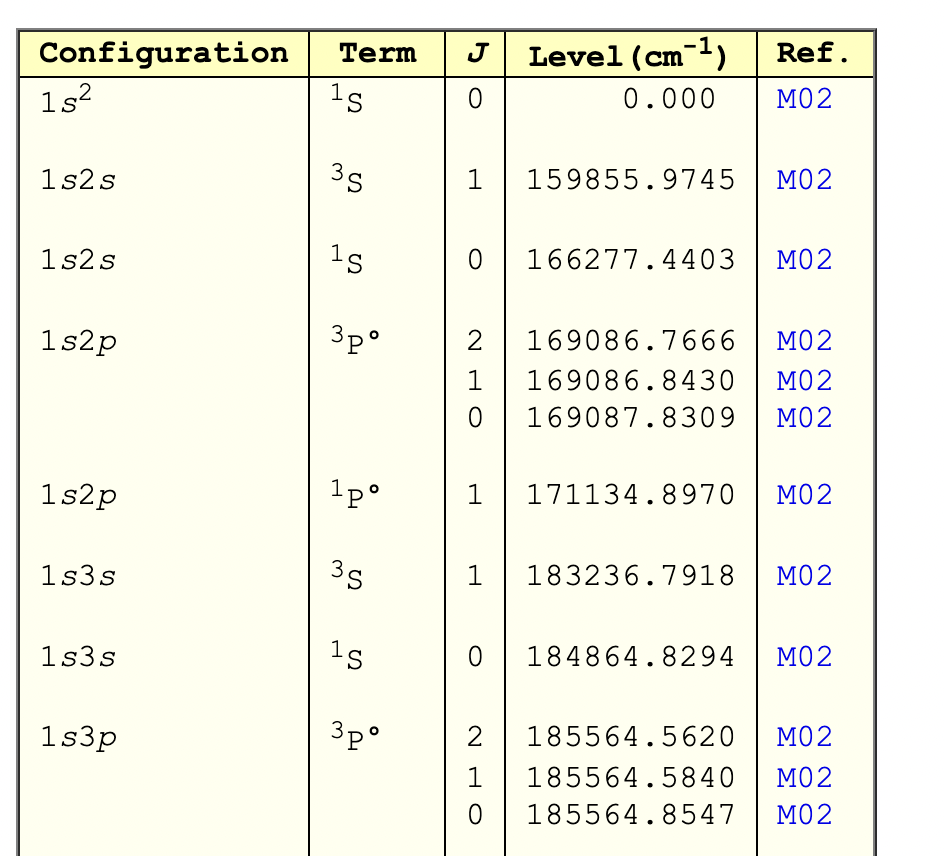,
from this we can get splitting of 645 cm-1 or 0.08eV, so the difference is still kinda big.